<a href="https://colab.research.google.com/github/jzazueta/data-science-business-econ/blob/main/notebooks/ch02_data_tools_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 2: Data, Tools, and Workflow

**Data Science for Business and Economics: A Python Approach**  
Jorge Zazueta — School of Economics, UASLP

---

This notebook accompanies Chapter 2. Unlike Chapter 1, this chapter contains no
code examples in the main text — it is conceptual. This notebook serves two purposes:

1. **Tool demonstrations** — brief, executable examples of each library introduced
   in Section 2.3, so you can see the ecosystem in action before Chapter 3 develops it fully.
2. **MedPoint workflow sketch** — a synthetic version of the MedPoint market entry
   analysis that traces all five workflow stages with real code.

> **Note:** All data in this notebook is synthetically generated. The MedPoint
> company and datasets are fictional illustrations used in Chapter 2.

## Setup

Run this cell first. Installs any missing packages and imports all libraries used in this chapter.

In [1]:
# LISTING: setup
# STATUS: draft

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import statsmodels.api as sm

# Reproducibility
np.random.seed(42)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

---
## Section 2.3 — Tool Demonstrations

The following cells give you a first look at each library in the Python data science
ecosystem. The examples are intentionally brief — each library is developed in depth
in later chapters.

### pandas — Loading, inspecting, and filtering tabular data

pandas is organized around the `DataFrame` — a two-dimensional table with labeled
rows and columns. The three operations below — load, inspect, filter — are the
first things you do with any structured dataset.

In [2]:
# LISTING: 2.demo_pandas
# STATUS: draft

# Create a small structured dataset — similar in form to the MedPoint Census file
demographics = pd.DataFrame({
    'zip_code':       ['85001', '85002', '85003', '85004', '85005'],
    'population':     [12400,   8900,    15200,   6300,    11800],
    'pct_65_plus':    [0.18,    0.12,    0.24,    0.09,    0.21],
    'median_income':  [52000,   38000,   61000,   29000,   47000],
    'insured_pct':    [0.84,    0.71,    0.89,    0.63,    0.78],
})

# Inspect structure
print("Shape:", demographics.shape)
print("\nColumn types:")
print(demographics.dtypes)
print("\nFirst rows:")
demographics.head()

Shape: (5, 5)

Column types:
zip_code          object
population         int64
pct_65_plus      float64
median_income      int64
insured_pct      float64
dtype: object

First rows:


,zip_code,population,pct_65_plus,median_income,insured_pct
0,85001,12400,0.18,52000,0.84
1,85002,8900,0.12,38000,0.71
2,85003,15200,0.24,61000,0.89
3,85004,6300,0.09,29000,0.63
4,85005,11800,0.21,47000,0.78


In [3]:
# LISTING: 2.demo_pandas_filter
# STATUS: draft

# Filter: ZIP codes with above-average share of elderly residents
avg_elderly = demographics['pct_65_plus'].mean()
high_elderly = demographics[demographics['pct_65_plus'] > avg_elderly]

print(f"Average share aged 65+: {avg_elderly:.1%}")
print(f"ZIP codes above average: {len(high_elderly)}")
high_elderly[['zip_code', 'pct_65_plus', 'median_income']]

Average share aged 65+: 16.8%
ZIP codes above average: 3


,zip_code,pct_65_plus,median_income
0,85001,0.18,52000
2,85003,0.24,61000
4,85005,0.21,47000


### NumPy — Numerical computation at the array level

NumPy operates beneath pandas. Most analysts interact with it indirectly, but
it becomes visible when working with model outputs, performing element-wise
operations, or handling large numerical arrays efficiently.

In [4]:
# LISTING: 2.demo_numpy
# STATUS: draft

# NumPy arrays support vectorized operations — no loops needed
incomes = np.array([52000, 38000, 61000, 29000, 47000])
elderly = np.array([0.18, 0.12, 0.24, 0.09, 0.21])

# Element-wise: estimated pharmacy-relevant population per ZIP
population  = np.array([12400, 8900, 15200, 6300, 11800])
elderly_pop = population * elderly

print("Estimated elderly residents per ZIP:")
for z, e in zip(['85001','85002','85003','85004','85005'], elderly_pop):
    print(f"  {z}: {e:,.0f}")

print(f"\nMean: {elderly_pop.mean():,.0f}")
print(f"Std:  {elderly_pop.std():,.0f}")

Estimated elderly residents per ZIP:
  85001: 2,232
  85002: 1,068
  85003: 3,648
  85004: 567
  85005: 2,478

Mean: 1,999
Std:  1,088


### Matplotlib and seaborn — Visualization

Matplotlib gives precise, low-level control over figures. seaborn provides
a higher-level interface for statistical graphics. In practice, you use both:
seaborn for the initial chart, Matplotlib for fine-tuning and annotation.

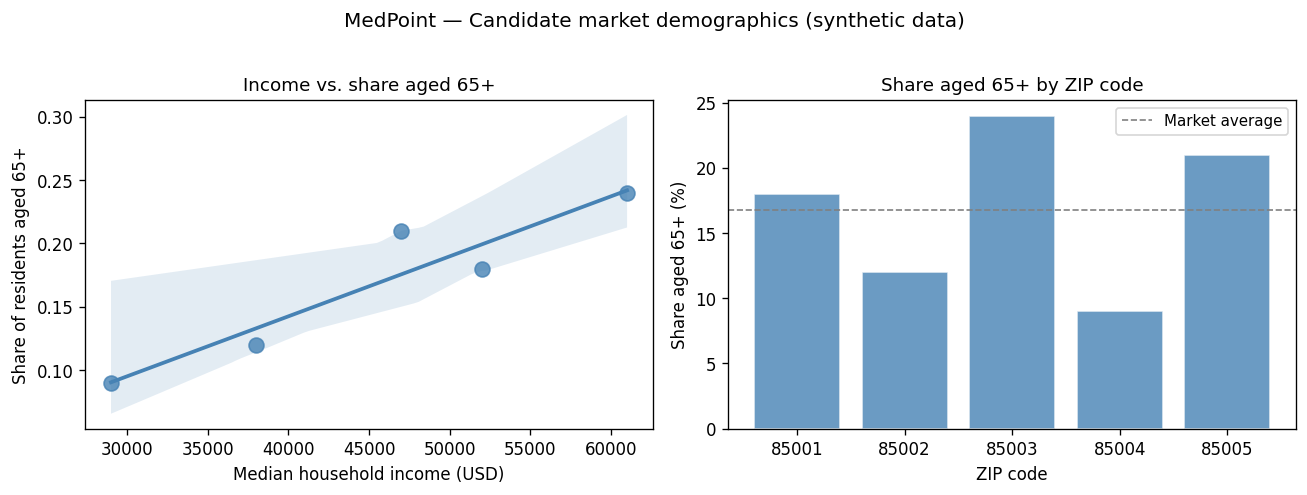

In [5]:
# LISTING: 2.demo_visualization
# STATUS: draft

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# seaborn: scatter plot with a regression line
sns.regplot(
    data=demographics, x='median_income', y='pct_65_plus',
    ax=axes[0], color='steelblue', scatter_kws={'s': 80}
)
axes[0].set_title('Income vs. share aged 65+', fontsize=11)
axes[0].set_xlabel('Median household income (USD)')
axes[0].set_ylabel('Share of residents aged 65+')

# Matplotlib: bar chart with annotation
axes[1].bar(
    demographics['zip_code'],
    demographics['pct_65_plus'] * 100,
    color='steelblue', alpha=0.8, edgecolor='white'
)
axes[1].axhline(
    demographics['pct_65_plus'].mean() * 100,
    color='gray', linestyle='--', linewidth=1, label='Market average'
)
axes[1].set_title('Share aged 65+ by ZIP code', fontsize=11)
axes[1].set_xlabel('ZIP code')
axes[1].set_ylabel('Share aged 65+ (%)')
axes[1].legend(fontsize=9)

plt.suptitle('MedPoint — Candidate market demographics (synthetic data)',
             y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

### statsmodels — Statistical inference

statsmodels is organized around inference: it produces coefficient estimates,
standard errors, confidence intervals, and hypothesis tests. This is the library
an economist reaches for when the goal is to *understand* a relationship, not
just predict an outcome.

In [6]:
# LISTING: 2.demo_statsmodels
# STATUS: draft

# Simple regression: does share aged 65+ predict median income?
X = sm.add_constant(demographics['pct_65_plus'])  # adds intercept
y = demographics['median_income']

model = sm.OLS(y, X).fit()

# statsmodels produces a full inference table, not just a prediction
print(model.summary().tables[1])  # coefficients table only

                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        1.388e+04   6792.848      2.044      0.134   -7734.152    3.55e+04
pct_65_plus  1.876e+05   3.84e+04      4.887      0.016    6.54e+04     3.1e+05


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


### scikit-learn — Prediction and scoring

scikit-learn is organized around prediction: a consistent interface for
fitting models, transforming data, and scoring new observations. Here it
is used to normalize variables onto a common scale — a common preprocessing
step before building a composite index.

In [7]:
# LISTING: 2.demo_sklearn
# STATUS: draft

# Normalize two variables onto [0, 1] to combine them into an index
scaler = MinMaxScaler()

scaled = scaler.fit_transform(
    demographics[['pct_65_plus', 'median_income']]
)

demographics['elderly_score'] = scaled[:, 0]
demographics['income_score']  = scaled[:, 1]

print("Normalized variables (0 = lowest in sample, 1 = highest):")
demographics[['zip_code', 'pct_65_plus', 'elderly_score',
              'median_income', 'income_score']]

Normalized variables (0 = lowest in sample, 1 = highest):


,zip_code,pct_65_plus,elderly_score,median_income,income_score
0,85001,0.18,0.6,52000,0.71875
1,85002,0.12,0.2,38000,0.28125
2,85003,0.24,1.0,61000,1.00000
3,85004,0.09,0.0,29000,0.00000
4,85005,0.21,0.8,47000,0.56250


---
## Section 2.4 — The MedPoint Workflow: A Synthetic End-to-End Sketch

The following cells trace all five workflow stages using synthetic data that
mimics the structure of the three MedPoint datasets. The goal is not to produce
a real analysis — the data is fabricated — but to show what each stage looks like
in code before the methods are developed in Part 2.

The five stages: **Question → Data → Exploration → Modeling → Communication**

### Stage 1: Question

*Which ZIP codes in the three candidate markets offer the largest estimated
revenue opportunity per new location, net of competitive pressure?*

The unit of analysis is the ZIP code. The outcome of interest is a composite
opportunity index combining predicted spending and inverse competitor density.
The information constraint is the three datasets described in Section 2.1.

### Stage 2: Data

Assemble and inspect the three datasets. In a real project these would be
loaded from files or APIs. Here we generate them synthetically.

In [8]:
# LISTING: 2.workflow_data
# STATUS: draft

n_zips = 60  # 20 ZIP codes per candidate market

# Dataset 1: Census demographics (structured, cross-sectional, administrative)
census = pd.DataFrame({
    'zip_code':      [f'ZIP_{i:03d}' for i in range(n_zips)],
    'market':        ['A']*20 + ['B']*20 + ['C']*20,
    'population':    np.random.randint(5000, 25000, n_zips),
    'pct_65_plus':   np.clip(np.random.normal(0.17, 0.06, n_zips), 0.05, 0.40),
    'median_income': np.random.randint(28000, 90000, n_zips),
    'insured_pct':   np.clip(np.random.normal(0.80, 0.10, n_zips), 0.50, 0.99),
})

# Dataset 2: Competitor locations (semi-structured, cross-sectional, commercial)
competitors = pd.DataFrame({
    'zip_code':        census['zip_code'],
    'competitor_count': np.random.poisson(lam=2.5, size=n_zips),
})

# Dataset 3: Consumer spending panel (structured, longitudinal, commercial)
# 200 households, 12 months each = 2,400 records
n_households = 200
n_months = 12
hh_zip = np.random.choice(census['zip_code'], n_households)

spending_records = []
for hh_id, zip_code in enumerate(hh_zip):
    income = census.loc[census['zip_code']==zip_code, 'median_income'].values[0]
    elderly = census.loc[census['zip_code']==zip_code, 'pct_65_plus'].values[0]
    base = 40 + (income / 5000) + (elderly * 300) + np.random.normal(0, 15)
    for month in range(1, n_months + 1):
        # Introduce ~8% missing data to simulate real-world panel
        if np.random.rand() < 0.08:
            monthly_spend = np.nan
        else:
            monthly_spend = max(0, base + np.random.normal(0, 20))
        spending_records.append({
            'household_id': f'HH_{hh_id:04d}',
            'zip_code': zip_code,
            'month': month,
            'monthly_spend': monthly_spend,
        })

spending = pd.DataFrame(spending_records)

print(f"Census:      {census.shape[0]} ZIP codes, {census.shape[1]} variables")
print(f"Competitors: {competitors.shape[0]} ZIP codes")
print(f"Spending:    {spending.shape[0]} household-month records")
print(f"             Missing: {spending['monthly_spend'].isna().mean():.1%}")

Census:      60 ZIP codes, 6 variables
Competitors: 60 ZIP codes
Spending:    2400 household-month records
             Missing: 8.2%


### Stage 3: Exploration

Before modeling, examine the data. Two questions drive MedPoint's exploration:
which demographic variable has the strongest relationship with pharmacy spending,
and is the missing data in the spending panel random?

In [9]:
# LISTING: 2.workflow_exploration
# STATUS: draft

# Aggregate spending to ZIP level (mean monthly spend per household)
zip_spend = (
    spending.groupby('zip_code')['monthly_spend']
    .mean()
    .reset_index()
    .rename(columns={'monthly_spend': 'avg_monthly_spend'})
)

# Merge all three datasets into one analytical table
analysis = census.merge(competitors, on='zip_code').merge(zip_spend, on='zip_code')

# Correlation of demographic variables with pharmacy spending
demo_vars = ['pct_65_plus', 'median_income', 'insured_pct', 'population']
correlations = analysis[demo_vars + ['avg_monthly_spend']].corr()['avg_monthly_spend'].drop('avg_monthly_spend')

print("Correlation with average monthly pharmacy spending:")
print(correlations.sort_values(ascending=False).to_string())
print("\n→ pct_65_plus has the strongest relationship — consistent with the chapter narrative.")

Correlation with average monthly pharmacy spending:
pct_65_plus      0.871828
median_income    0.091203
insured_pct      0.022249
population      -0.044181

→ pct_65_plus has the strongest relationship — consistent with the chapter narrative.


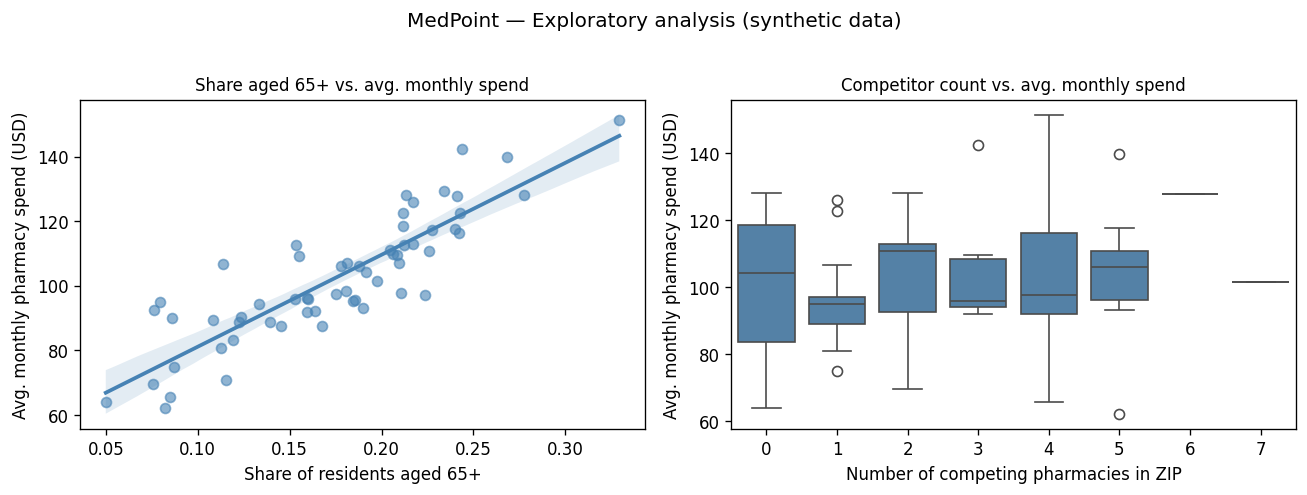

In [10]:
# LISTING: 2.workflow_exploration_plot
# STATUS: draft

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: pct_65_plus vs. spending
sns.regplot(
    data=analysis, x='pct_65_plus', y='avg_monthly_spend',
    ax=axes[0], color='steelblue', scatter_kws={'alpha': 0.6}
)
axes[0].set_title('Share aged 65+ vs. avg. monthly spend', fontsize=10)
axes[0].set_xlabel('Share of residents aged 65+')
axes[0].set_ylabel('Avg. monthly pharmacy spend (USD)')

# Right: competitor count vs. spending
sns.boxplot(
    data=analysis, x='competitor_count', y='avg_monthly_spend',
    ax=axes[1], color='steelblue'
)
axes[1].set_title('Competitor count vs. avg. monthly spend', fontsize=10)
axes[1].set_xlabel('Number of competing pharmacies in ZIP')
axes[1].set_ylabel('Avg. monthly pharmacy spend (USD)')

plt.suptitle('MedPoint — Exploratory analysis (synthetic data)', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

### Stage 4: Modeling

Two steps: estimate the relationship between demographics and spending
(statsmodels), then score each ZIP code on a composite opportunity index
(scikit-learn).

In [11]:
# LISTING: 2.workflow_modeling
# STATUS: draft

# Step 1: Regression — demographics → predicted spending (statsmodels)
analysis_clean = analysis.dropna(subset=['avg_monthly_spend'])

X = sm.add_constant(analysis_clean[['pct_65_plus', 'median_income', 'insured_pct']])
y = analysis_clean['avg_monthly_spend']

reg = sm.OLS(y, X).fit()
analysis_clean = analysis_clean.copy()
analysis_clean['predicted_spend'] = reg.predict(X)

print(f"R²: {reg.rsquared:.3f}")
print(f"Key coefficient — pct_65_plus: {reg.params['pct_65_plus']:.2f} "
      f"(p={reg.pvalues['pct_65_plus']:.3f})")

R²: 0.809
Key coefficient — pct_65_plus: 295.99 (p=0.000)


In [12]:
# LISTING: 2.workflow_scoring
# STATUS: draft

# Step 2: Composite opportunity index (scikit-learn MinMaxScaler)
# Opportunity = 0.6 × predicted spend score + 0.4 × whitespace score
# Whitespace = inverse of competitor count (more competitors = less whitespace)

analysis_clean = analysis_clean.copy()
analysis_clean['whitespace'] = 1 / (analysis_clean['competitor_count'] + 1)

scaler = MinMaxScaler()
scores = scaler.fit_transform(
    analysis_clean[['predicted_spend', 'whitespace']]
)

analysis_clean['opportunity_index'] = 0.6 * scores[:, 0] + 0.4 * scores[:, 1]

# Top 5 ZIP codes overall
top5 = analysis_clean.nlargest(5, 'opportunity_index')[
    ['zip_code', 'market', 'pct_65_plus', 'competitor_count',
     'predicted_spend', 'opportunity_index']
]
print("Top 5 ZIP codes by opportunity index:")
print(top5.to_string(index=False))

Top 5 ZIP codes by opportunity index:
zip_code market  pct_65_plus  competitor_count  predicted_spend  opportunity_index
 ZIP_030      B     0.242730                 0       120.898974           0.803917
 ZIP_043      C     0.227670                 0       115.720783           0.769743
 ZIP_051      C     0.206485                 0       112.808968           0.750527
 ZIP_013      A     0.213290                 0       108.372387           0.721247
 ZIP_023      B     0.180416                 0        99.075189           0.659890


### Stage 5: Communication

Translate the model output into a board-ready visualization: the top-scoring
ZIP codes by market, with the opportunity index as the ranking criterion.

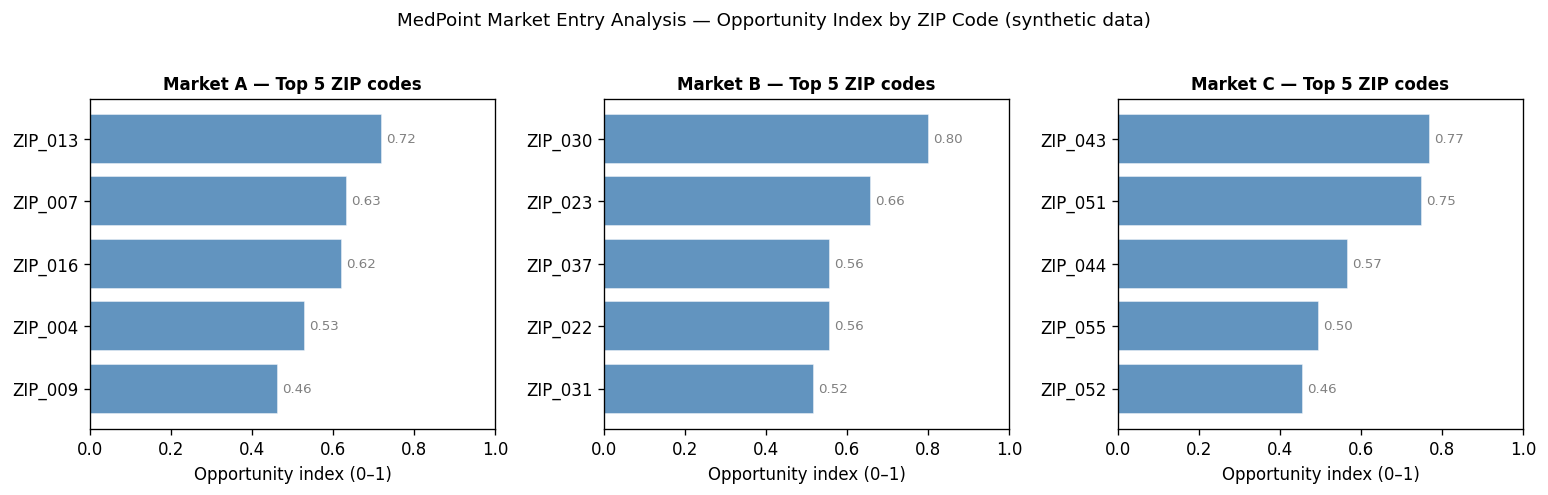


Recommendation: Enter Market B first.
Rationale: highest average opportunity index across ZIP codes,
driven by above-average elderly population share and below-average competitor density.


In [13]:
# LISTING: 2.workflow_communication
# STATUS: draft

# Top 5 ZIP codes per market
top_per_market = (
    analysis_clean
    .sort_values('opportunity_index', ascending=False)
    .groupby('market')
    .head(5)
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)

for ax, market in zip(axes, ['A', 'B', 'C']):
    data = top_per_market[top_per_market['market'] == market]
    bars = ax.barh(
        data['zip_code'], data['opportunity_index'],
        color='steelblue', alpha=0.85, edgecolor='white'
    )
    ax.set_title(f'Market {market} — Top 5 ZIP codes', fontsize=10, fontweight='bold')
    ax.set_xlabel('Opportunity index (0–1)')
    ax.set_xlim(0, 1)
    ax.invert_yaxis()
    # Annotate bars with index value
    for bar, val in zip(bars, data['opportunity_index']):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', fontsize=8, color='gray')

plt.suptitle(
    'MedPoint Market Entry Analysis — Opportunity Index by ZIP Code (synthetic data)',
    y=1.02, fontsize=11
)
plt.tight_layout()
plt.show()

# Recommendation summary
best_market = (
    analysis_clean.groupby('market')['opportunity_index']
    .mean()
    .idxmax()
)
print(f"\nRecommendation: Enter Market {best_market} first.")
print("Rationale: highest average opportunity index across ZIP codes,")
print("driven by above-average elderly population share and below-average competitor density.")

---
## Exercises

Use the cells below to work through the end-of-chapter exercises.  
Exercises marked *open-ended* do not have a unique correct answer — they require judgment, not just computation.

In [14]:
# Exercise 2.1
# Choose a real dataset you are familiar with and classify it using the
# taxonomy in Table 2.1: structure, observation design, and source.
# Write your classification as comments below and explain what questions
# the dataset can and cannot support.


In [15]:
# Exercise 2.2
# Write two alternative formulations of the MedPoint business question.
# For each, identify: (a) the unit of analysis, (b) the outcome of interest,
# and (c) how it would change the analytical approach.
# Write your answer as comments or a markdown cell below.


In [16]:
# Exercise 2.3
# The spending panel has ~8% missing data.
# (a) Check whether missingness is evenly distributed across markets.
# (b) Explain in a comment why naive mean imputation could bias the results.

missing_by_market = (
    spending
    .merge(census[['zip_code', 'market']], on='zip_code')
    .groupby('market')['monthly_spend']
    .apply(lambda x: x.isna().mean())
)
print("Missing rate by market:")
print(missing_by_market)

# Your interpretation:


Missing rate by market:
market
A    0.065476
B    0.092448
C    0.089646
Name: monthly_spend, dtype: float64


In [17]:
# Exercise 2.4
# For each task below, write the code and identify which library you used:
# (a) Load a CSV file and filter rows where a column exceeds a threshold.
# (b) Compute the mean and standard deviation of a numeric array.
# (c) Fit a linear regression and print the slope's 95% confidence interval.
# (d) Produce a histogram of monthly_spend with a kernel density overlay.


In [18]:
# Exercise 2.5 (Challenge)
# Sketch a five-stage workflow for a business problem of your choice
# involving at least two datasets from different sources.
# For each stage write 2-3 sentences of code comments describing what
# the stage would involve in your specific context.
# Pay particular attention to Stage 1: write a precise analytical question,
# identify an alternative formulation, and explain your preference.

# Stage 1 — Question:

# Stage 2 — Data:

# Stage 3 — Exploration:

# Stage 4 — Modeling:

# Stage 5 — Communication:
